# Hard Outlier Filters — Domain Knowledge

**Note:** High incomes, high loan amounts, and `loan_percent_income > 1` are NOT filtered —
these are unusual but valid (e.g. medical debt, high earners). They are handled by
Isolation Forest weighting in Phase 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("..")
RAW_PATH     = PROJECT_ROOT / "data" / "raw"           / "loan_data.csv"

print("Raw data:     ", RAW_PATH)

Raw data:      ../data/raw/loan_data.csv


## Load raw data

In [2]:
raw = pd.read_csv(RAW_PATH)
total_rows = len(raw)
print(f"Raw data shape: {raw.shape}")
raw.head()

Raw data shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Inspect the columns relevant to hard filters

Quick look at the min/max of each column we will filter on — confirms the bad values are present.

In [3]:
filter_cols = [
    "person_age", "person_emp_exp", "credit_score",
    "person_income", "loan_amnt", "loan_int_rate",
    "loan_percent_income", "cb_person_cred_hist_length"
]
raw[filter_cols].describe().loc[["min", "max", "mean", "50%"]]

,person_age,person_emp_exp,credit_score,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
min,20.000000,0.000000,390.000000,8.000000e+03,500.000000,5.420000,0.000000,2.000000
max,144.000000,125.000000,850.000000,7.200766e+06,35000.000000,20.000000,0.660000,30.000000
mean,27.764178,5.410333,632.608756,8.031905e+04,9583.157556,11.006606,0.139725,5.867489
50%,26.000000,4.000000,640.000000,6.704800e+04,8000.000000,11.010000,0.120000,4.000000


## Define hard filters and report per-rule counts + percentages

In [4]:
# Each mask is True for rows that are BAD (should be removed)
filters = {
    "age < 18 (below legal loan age)"             : raw["person_age"] < 18,
    "age > 120 (physiologically impossible)"      : raw["person_age"] > 120,
    "emp_exp < 0 (negative experience)"           : raw["person_emp_exp"] < 0,
    "emp_exp > 80 (impossible career length)"     : raw["person_emp_exp"] > 80,
    "emp_exp > (age-16) (worked before age 16)"   : raw["person_emp_exp"] > (raw["person_age"] - 16),
    "credit_score < 300 (below FICO floor)"       : raw["credit_score"] < 300,
    "credit_score > 850 (above FICO ceiling)"     : raw["credit_score"] > 850,
    "income <= 0 (non-positive income)"           : raw["person_income"] <= 0,
    "loan_amnt <= 0 (non-positive loan)"          : raw["loan_amnt"] <= 0,
    "interest_rate < 0 (negative rate)"           : raw["loan_int_rate"] < 0,
    "interest_rate > 100 (illegal interest rate / error)"         : raw["loan_int_rate"] > 100,
    "loan_percent_income < 0 (negative ratio)"    : raw["loan_percent_income"] < 0,
    "cred_hist > age (history longer than life)"  : raw["cb_person_cred_hist_length"] > raw["person_age"],
}

# Per-filter report: count AND % of total data
print(f"{'Filter Rule':<50} {'Count':>8}  {'% of Total':>10}")
print("-" * 73)
for name, mask in filters.items():
    n = mask.sum()
    print(f"{name:<50} {n:>8,}  {n / total_rows * 100:>9.3f}%")

# Combined mask: bad if ANY rule flags it
bad_mask = pd.concat(filters.values(), axis=1).any(axis=1)
hard_filter_indices = set(raw.index[bad_mask])   # saved for overlap analysis below

print("-" * 73)
print(f"{'TOTAL unique bad rows (any rule)':<50} {bad_mask.sum():>8,}  {bad_mask.mean() * 100:>9.3f}%")
print(f"{'Rows remaining after removal':<50} {(~bad_mask).sum():>8,}  {(~bad_mask).mean() * 100:>9.3f}%")

Filter Rule                                           Count  % of Total
-------------------------------------------------------------------------
age < 18 (below legal loan age)                           0      0.000%
age > 120 (physiologically impossible)                    5      0.011%
emp_exp < 0 (negative experience)                         0      0.000%
emp_exp > 80 (impossible career length)                   7      0.016%
emp_exp > (age-16) (worked before age 16)                 0      0.000%
credit_score < 300 (below FICO floor)                     0      0.000%
credit_score > 850 (above FICO ceiling)                   0      0.000%
income <= 0 (non-positive income)                         0      0.000%
loan_amnt <= 0 (non-positive loan)                        0      0.000%
interest_rate < 0 (negative rate)                         0      0.000%
interest_rate > 100 (illegal interest rate / error)                       0      0.000%
loan_percent_income < 0 (negative ratio)      

## Examine the removed rows

Show the actual bad records so we can sanity check them — the 144-year-old should appear here.

In [5]:
bad_rows = raw[bad_mask][filter_cols].copy()

# Tag which rules triggered for each bad row
for rule_name, mask in filters.items():
    bad_rows[f"flag: {rule_name[:32]}"] = mask[bad_mask].values

print(f"{len(bad_rows)} bad rows found:")
bad_rows.sort_values("person_age", ascending=False)

7 bad rows found:


,person_age,person_emp_exp,credit_score,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,flag: age < 18 (below legal loan age),flag: age > 120 (physiologically impos,...,flag: emp_exp > 80 (impossible career,flag: emp_exp > (age-16) (worked befor,flag: credit_score < 300 (below FICO f,flag: credit_score > 850 (above FICO c,flag: income <= 0 (non-positive income,flag: loan_amnt <= 0 (non-positive loa,flag: interest_rate < 0 (negative rate,flag: interest_rate > 100 (illegal interest rate / err,flag: loan_percent_income < 0 (negativ,flag: cred_hist > age (history longer
81,144.0,125,789,300616.0,4800.0,13.57,0.02,3.0,False,True,...,True,False,False,False,False,False,False,False,False,False
183,144.0,121,807,241424.0,6000.0,11.86,0.02,2.0,False,True,...,True,False,False,False,False,False,False,False,False,False
32297,144.0,124,850,7200766.0,5000.0,12.73,0.00,25.0,False,True,...,True,False,False,False,False,False,False,False,False,False
575,123.0,101,805,97140.0,20400.0,10.25,0.21,3.0,False,True,...,True,False,False,False,False,False,False,False,False,False
747,123.0,100,714,94723.0,20000.0,11.01,0.21,4.0,False,True,...,True,False,False,False,False,False,False,False,False,False
37930,116.0,93,708,5545545.0,3823.0,12.15,0.00,24.0,False,False,...,True,False,False,False,False,False,False,False,False,False
38113,109.0,85,792,5556399.0,6195.0,12.58,0.00,22.0,False,False,...,True,False,False,False,False,False,False,False,False,False


## Visualise — before vs after distributions

Overlay histograms for the most affected columns to confirm the filters are working correctly
and not removing legitimate data.

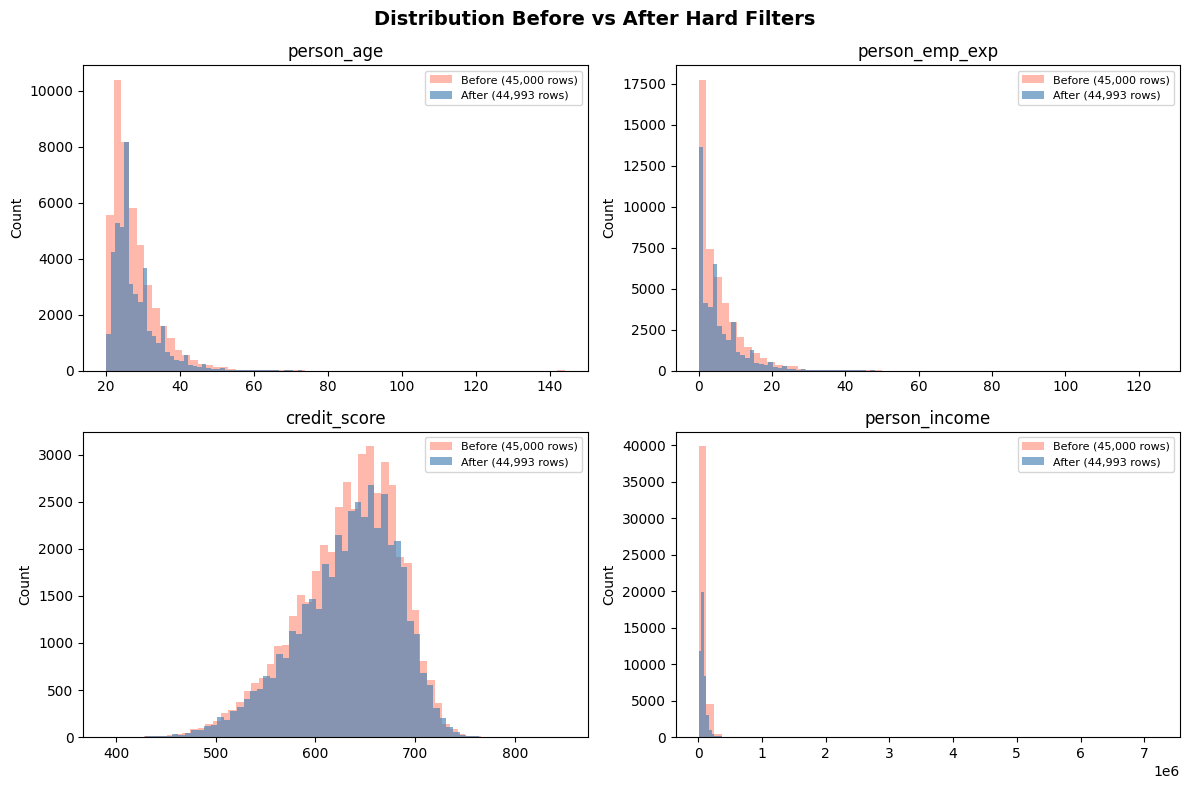

In [6]:
clean_raw = raw[~bad_mask].copy()

plot_cols = ["person_age", "person_emp_exp", "credit_score", "person_income"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    ax.hist(raw[col].dropna(), bins=60, alpha=0.45, color="tomato",
            label=f"Before ({total_rows:,} rows)")
    ax.hist(clean_raw[col].dropna(), bins=60, alpha=0.65, color="steelblue",
            label=f"After ({len(clean_raw):,} rows)")
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_ylabel("Count")

fig.suptitle("Distribution Before vs After Hard Filters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Save outputs

Files will be suffixed with _filtered, to identify these files as having the 7 bad outliers removed.

In [7]:
# Save filtered raw data
clean_raw_path = PROJECT_ROOT / "data" / "raw" / "loan_data_hard_filtered.csv"
clean_raw.to_csv(clean_raw_path, index=False)
print(f"Saved filtered raw data → {clean_raw_path}  {clean_raw.shape}")

Saved filtered raw data → ../data/raw/loan_data_hard_filtered.csv  (44993, 14)


## Summary report

In [8]:
print("=" * 65)
print("HARD FILTER SUMMARY")
print("=" * 65)
print(f"  Original rows:        {total_rows:>8,}")
print(f"  Bad rows removed:     {bad_mask.sum():>8,}  ({bad_mask.mean() * 100:.3f}%)")
print(f"  Clean rows remaining: {(~bad_mask).sum():>8,}")
print()
print("OUTPUT FILES")
print("  data/raw/loan_data_hard_filtered.csv")


HARD FILTER SUMMARY
  Original rows:          45,000
  Bad rows removed:            7  (0.016%)
  Clean rows remaining:   44,993

OUTPUT FILES
  data/raw/loan_data_hard_filtered.csv
